# Supervised Classification Analysis

This notebook analyzes three datasets using two different classification algorithms:
1. MNIST Digits
2. SpamBase
3. 20 NewsGroups

For each dataset, we'll use:
- L2-regularized Logistic Regression
- Decision Trees

We'll analyze the top 30 features for each model.

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import seaborn as sns


## 1. MNIST Dataset Analysis

In [2]:
from sklearn.datasets import fetch_openml

X_mnist, y_mnist = fetch_openml('mnist_784', version=1, return_X_y=True)

# Split the data
X_train_mnist, X_test_mnist, y_train_mnist, y_test_mnist = train_test_split(
    X_mnist, y_mnist, test_size=0.2, random_state=42
)

# Scale the features
scaler = StandardScaler()
X_train_mnist_scaled = scaler.fit_transform(X_train_mnist)
X_test_mnist_scaled = scaler.transform(X_test_mnist)

In [3]:
# Train Logistic Regression
lr_mnist = LogisticRegression(max_iter=1000, multi_class='multinomial')
lr_mnist.fit(X_train_mnist_scaled, y_train_mnist)
lr_mnist_score = lr_mnist.score(X_test_mnist_scaled, y_test_mnist)

# Train Decision Tree
dt_mnist = DecisionTreeClassifier(random_state=42)
dt_mnist.fit(X_train_mnist_scaled, y_train_mnist)
dt_mnist_score = dt_mnist.score(X_test_mnist_scaled, y_test_mnist)

print(f"MNIST - Logistic Regression Accuracy: {lr_mnist_score:.4f}")
print(f"MNIST - Decision Tree Accuracy: {dt_mnist_score:.4f}")

C:\Users\prani\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


MNIST - Logistic Regression Accuracy: 0.9163
MNIST - Decision Tree Accuracy: 0.8697


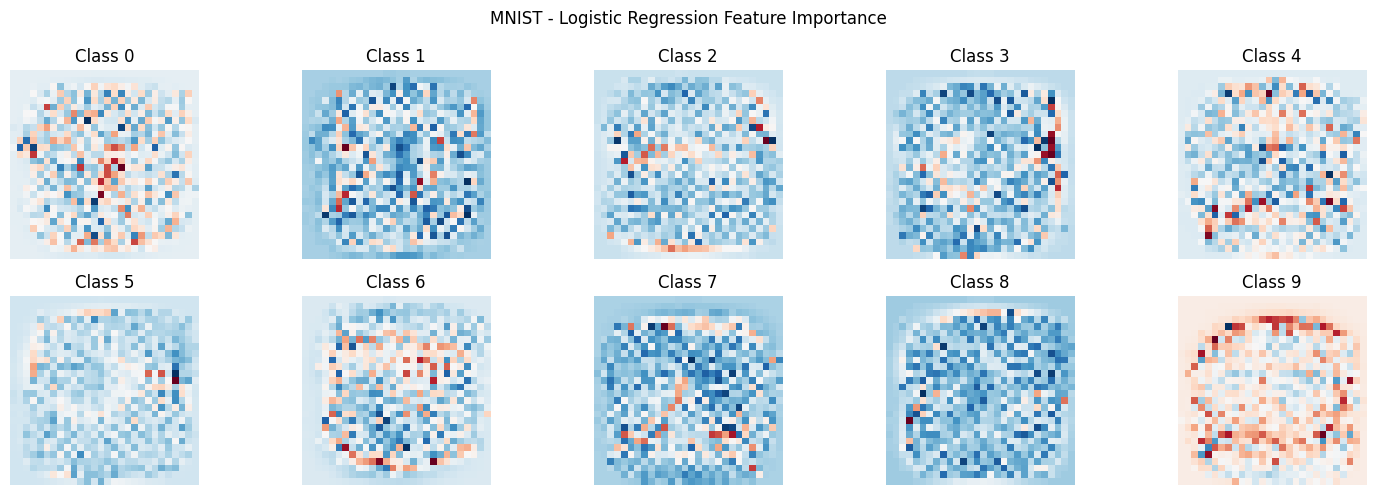


Top 30 Important Features (Decision Tree):
     feature  importance
489      489    0.054718
435      435    0.046294
350      350    0.044905
347      347    0.043532
542      542    0.039301
211      211    0.036363
486      486    0.033081
432      432    0.032407
270      270    0.029995
597      597    0.026581
155      155    0.026108
354      354    0.018324
273      273    0.017428
206      206    0.015544
290      290    0.015132
296      296    0.014643
405      405    0.012599
656      656    0.011879
657      657    0.010752
352      352    0.009629
596      596    0.008046
404      404    0.007787
372      372    0.007184
297      297    0.007042
658      658    0.006832
380      380    0.006796
267      267    0.006297
457      457    0.005853
490      490    0.005549
598      598    0.005228


In [4]:
def plot_mnist_features(coef, title):
    plt.figure(figsize=(15, 5))
    for i in range(10):
        plt.subplot(2, 5, i + 1)
        plt.imshow(coef[i].reshape(28, 28), cmap='RdBu')
        plt.title(f'Class {i}')
        plt.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# Plot Logistic Regression coefficients
plot_mnist_features(lr_mnist.coef_, 'MNIST - Logistic Regression Feature Importance')

# Get top 30 features importance for Decision Tree
dt_importance = pd.DataFrame({
    'feature': range(784),
    'importance': dt_mnist.feature_importances_
}).sort_values('importance', key=abs, ascending=False).head(30)

print("\nTop 30 Important Features (Decision Tree):")
print(dt_importance)

## 2. SpamBase Dataset Analysis

In [5]:
# Load SpamBase data
spam = fetch_openml('spambase', version=1)
X_spam = spam.data
y_spam = spam.target

# Split the data
X_train_spam, X_test_spam, y_train_spam, y_test_spam = train_test_split(
    X_spam, y_spam, test_size=0.2, random_state=42
)

# Scale the features
scaler = StandardScaler()
X_train_spam_scaled = scaler.fit_transform(X_train_spam)
X_test_spam_scaled = scaler.transform(X_test_spam)

In [6]:
# Train Logistic Regression
lr_spam = LogisticRegression(max_iter=1000)
lr_spam.fit(X_train_spam_scaled, y_train_spam)
lr_spam_score = lr_spam.score(X_test_spam_scaled, y_test_spam)

# Train Decision Tree
dt_spam = DecisionTreeClassifier(random_state=42)
dt_spam.fit(X_train_spam_scaled, y_train_spam)
dt_spam_score = dt_spam.score(X_test_spam_scaled, y_test_spam)

print(f"SpamBase - Logistic Regression Accuracy: {lr_spam_score:.4f}")
print(f"SpamBase - Decision Tree Accuracy: {dt_spam_score:.4f}")

SpamBase - Logistic Regression Accuracy: 0.9197
SpamBase - Decision Tree Accuracy: 0.9197


In [7]:
# Get feature names
spam_features = spam.feature_names

# Analyze Logistic Regression coefficients
lr_importance_spam = pd.DataFrame({
    'feature': spam_features,
    'coefficient': lr_spam.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False).head(30)

# Analyze Decision Tree feature importance
dt_importance_spam = pd.DataFrame({
    'feature': spam_features,
    'importance': dt_spam.feature_importances_
}).sort_values('importance', ascending=False).head(30)

print("Top 30 Features (Logistic Regression):")
print(lr_importance_spam)
print("\nTop 30 Features (Decision Tree):")
print(dt_importance_spam)

Top 30 Features (Logistic Regression):
                       feature  coefficient
26            word_freq_george    -4.495194
24                word_freq_hp    -2.797139
40                word_freq_cs    -1.550284
43           word_freq_project    -1.483756
41           word_freq_meeting    -1.253503
52               char_freq_%24     1.236360
45               word_freq_edu    -1.163825
28               word_freq_lab    -1.004540
47        word_freq_conference    -1.000090
22               word_freq_000     0.978427
15              word_freq_free     0.897060
55  capital_run_length_longest     0.894089
6             word_freq_remove     0.858489
25               word_freq_hpl    -0.849043
3                 word_freq_3d     0.828225
53               char_freq_%23     0.806633
44                word_freq_re    -0.780294
34                word_freq_85    -0.770779
32              word_freq_data    -0.736038
56    capital_run_length_total     0.631452
19            word_freq_credit     0.

## 3. 20 NewsGroups Dataset Analysis

In [8]:
# Load 20 NewsGroups data
newsgroups = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))

# Convert text to TF-IDF features
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X_news = vectorizer.fit_transform(newsgroups.data)
y_news = newsgroups.target

# Split the data
X_train_news, X_test_news, y_train_news, y_test_news = train_test_split(
    X_news, y_news, test_size=0.2, random_state=42
)

In [9]:
# Train Logistic Regression
lr_news = LogisticRegression(max_iter=1000, multi_class='multinomial')
lr_news.fit(X_train_news, y_train_news)
lr_news_score = lr_news.score(X_test_news, y_test_news)

# Train Decision Trees with different depths
dt_news_shallow = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_news_deep = DecisionTreeClassifier(max_depth=20, random_state=42)

dt_news_shallow.fit(X_train_news, y_train_news)
dt_news_deep.fit(X_train_news, y_train_news)

dt_news_shallow_score = dt_news_shallow.score(X_test_news, y_test_news)
dt_news_deep_score = dt_news_deep.score(X_test_news, y_test_news)

print(f"20 NewsGroups - Logistic Regression Accuracy: {lr_news_score:.4f}")
print(f"20 NewsGroups - Decision Tree (depth=10) Accuracy: {dt_news_shallow_score:.4f}")
print(f"20 NewsGroups - Decision Tree (depth=20) Accuracy: {dt_news_deep_score:.4f}")

C:\Users\prani\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


20 NewsGroups - Logistic Regression Accuracy: 0.6891
20 NewsGroups - Decision Tree (depth=10) Accuracy: 0.2021
20 NewsGroups - Decision Tree (depth=20) Accuracy: 0.2775


# PROBLEM 2 : PCA library on MNIST

In [10]:
# Get feature names
feature_names = vectorizer.get_feature_names_out()

# Analyze Logistic Regression coefficients (average across all classes)
lr_importance_news = pd.DataFrame({
    'feature': feature_names,
    'coefficient': np.mean(np.abs(lr_news.coef_), axis=0)
}).sort_values('coefficient', ascending=False).head(30)

# Analyze Decision Tree feature importance (for both trees)
dt_importance_shallow = pd.DataFrame({
    'feature': feature_names,
    'importance': dt_news_shallow.feature_importances_
}).sort_values('importance', ascending=False).head(30)

dt_importance_deep = pd.DataFrame({
    'feature': feature_names,
    'importance': dt_news_deep.feature_importances_
}).sort_values('importance', ascending=False).head(30)

print("Top 30 Features (Logistic Regression):")
print(lr_importance_news)
print("\nTop 30 Features (Decision Tree - Shallow):")
print(dt_importance_shallow)
print("\nTop 30 Features (Decision Tree - Deep):")
print(dt_importance_deep)

Top 30 Features (Logistic Regression):
         feature  coefficient
2031         god     1.406046
4900     windows     1.250900
2046  government     1.138450
3315      people     1.092853
1530       drive     1.066891
873          car     1.056714
4717         use     1.035557
1965        game     0.992685
1107    computer     0.972031
3524     problem     0.946407
1834        file     0.940825
3545     program     0.927943
4527      thanks     0.916630
874         card     0.910583
2960     monitor     0.905743
4199    software     0.895104
4479        team     0.891876
4225       space     0.880903
702         bike     0.864684
969    christian     0.863034
1966       games     0.862859
2061    graphics     0.857058
2752         mac     0.850187
2466       jesus     0.847236
1511         dos     0.830177
3498       price     0.822707
4725       using     0.817787
3769    religion     0.816571
3306          pc     0.808392
697        bible     0.807038

Top 30 Features (Decision Tree

# PROBLEM 3 : Implement PCA on MNIST

In [11]:
def pca(X, d):
	"""
	Performs PCA on the given data X to reduce the dimensionality to d.

	Args:
		X (numpy.ndarray): The input data matrix of shape (n_samples, n_features).
		d (int): The desired reduced dimensionality.

	Returns:
		numpy.ndarray: The reduced data matrix of shape (n_samples, d).
		numpy.ndarray: The principal components (eigenvectors) of shape (n_features, d).
		numpy.ndarray: The explained variance ratio for each principal component.
	"""
	# Center the data
	X_mean = np.mean(X, axis=0)
	X_centered = X - X_mean

	# Calculate the covariance matrix
	covariance_matrix = np.cov(X_centered, rowvar=False)

	# Perform eigenvalue decomposition
	eigenvalues, eigenvectors = np.linalg.eig(covariance_matrix)

	# Sort eigenvalues and eigenvectors in descending order
	eigen_pairs = [(np.abs(eigenvalues[i]), eigenvectors[:, i]) for i in range(len(eigenvalues))]
	eigen_pairs.sort(key=lambda x: x[0], reverse=True)

	# Select the top d eigenvectors
	W = np.array([eigen_pairs[i][1] for i in range(d)]).T  # Principal components

	# Calculate explained variance ratio
	total_variance = np.sum(eigenvalues)
	explained_variance_ratio = np.array([eigen_pairs[i][0] / total_variance for i in range(d)])

	# Project the data onto the principal components
	X_reduced = X_centered @ W

	return X_reduced, W, explained_variance_ratio

# Apply PCA to MNIST data with d=5
d1 = 5
X_train_mnist_pca_5, W_mnist_5, explained_variance_ratio_5 = pca(X_train_mnist_scaled, d1)
X_test_mnist_pca_5, _, _ = pca(X_test_mnist_scaled, d1)

# Apply PCA to MNIST data with d=20
d2 = 20
X_train_mnist_pca_20, W_mnist_20, explained_variance_ratio_20 = pca(X_train_mnist_scaled, d2)
X_test_mnist_pca_20, _, _ = pca(X_test_mnist_scaled, d2)

print(f"Shape of X_train_mnist_pca_5: {X_train_mnist_pca_5.shape}")
print(f"Shape of X_test_mnist_pca_5: {X_test_mnist_pca_5.shape}")
print(f"Explained variance ratio (d=5): {explained_variance_ratio_5}")

print(f"\nShape of X_train_mnist_pca_20: {X_train_mnist_pca_20.shape}")
print(f"Shape of X_test_mnist_pca_20: {X_test_mnist_pca_20.shape}")
print(f"Explained variance ratio (d=20): {explained_variance_ratio_20}")

Shape of X_train_mnist_pca_5: (56000, 5)
Shape of X_test_mnist_pca_5: (14000, 5)
Explained variance ratio (d=5): [0.05674894 0.04052038 0.03759499 0.02907834 0.02528556]

Shape of X_train_mnist_pca_20: (56000, 20)
Shape of X_test_mnist_pca_20: (14000, 20)
Explained variance ratio (d=20): [0.05674894 0.04052038 0.03759499 0.02907834 0.02528556 0.02197258
 0.01914912 0.01756493 0.01531724 0.01394287 0.01346865 0.01210102
 0.01120584 0.01099131 0.01031526 0.00997519 0.00937808 0.00922133
 0.00892994 0.00863866]


# PROBLEM 4 : PCA for cluster visualization

KMeans Clustering Labels: [0 1 2 3 4 5 6 7 8 9]


C:\Users\prani\AppData\Local\Temp\ipykernel_6720\1224370302.py:32: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(cluster_data[:, 0], cluster_data[:, 1], cluster_data[:, 2],
C:\Users\prani\AppData\Local\Temp\ipykernel_6720\1224370302.py:32: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(cluster_data[:, 0], cluster_data[:, 1], cluster_data[:, 2],
C:\Users\prani\AppData\Local\Temp\ipykernel_6720\1224370302.

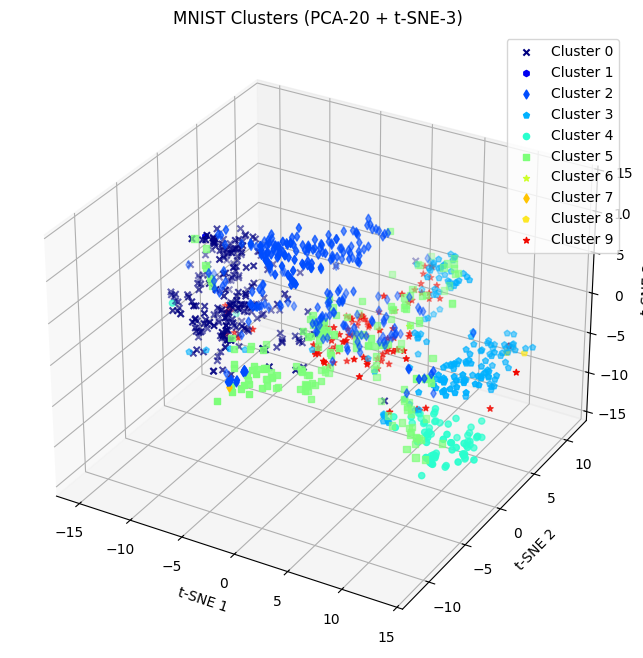

C:\Users\prani\AppData\Local\Temp\ipykernel_6720\1224370302.py:62: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(cluster_data[:, 0], cluster_data[:, 1], cluster_data[:, 2],
C:\Users\prani\AppData\Local\Temp\ipykernel_6720\1224370302.py:62: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(cluster_data[:, 0], cluster_data[:, 1], cluster_data[:, 2],
C:\Users\prani\AppData\Local\Temp\ipykernel_6720\1224370302.

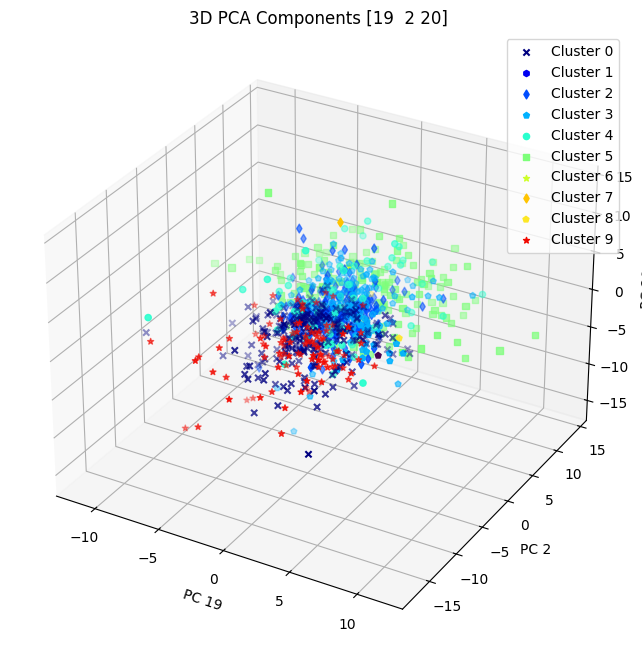

C:\Users\prani\AppData\Local\Temp\ipykernel_6720\1224370302.py:62: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(cluster_data[:, 0], cluster_data[:, 1], cluster_data[:, 2],
C:\Users\prani\AppData\Local\Temp\ipykernel_6720\1224370302.py:62: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(cluster_data[:, 0], cluster_data[:, 1], cluster_data[:, 2],
C:\Users\prani\AppData\Local\Temp\ipykernel_6720\1224370302.

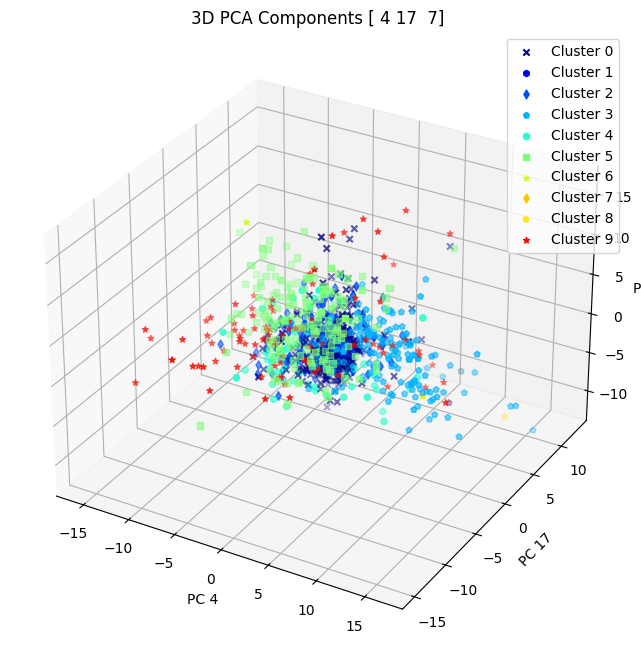

C:\Users\prani\AppData\Local\Temp\ipykernel_6720\1224370302.py:62: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(cluster_data[:, 0], cluster_data[:, 1], cluster_data[:, 2],
C:\Users\prani\AppData\Local\Temp\ipykernel_6720\1224370302.py:62: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(cluster_data[:, 0], cluster_data[:, 1], cluster_data[:, 2],
C:\Users\prani\AppData\Local\Temp\ipykernel_6720\1224370302.

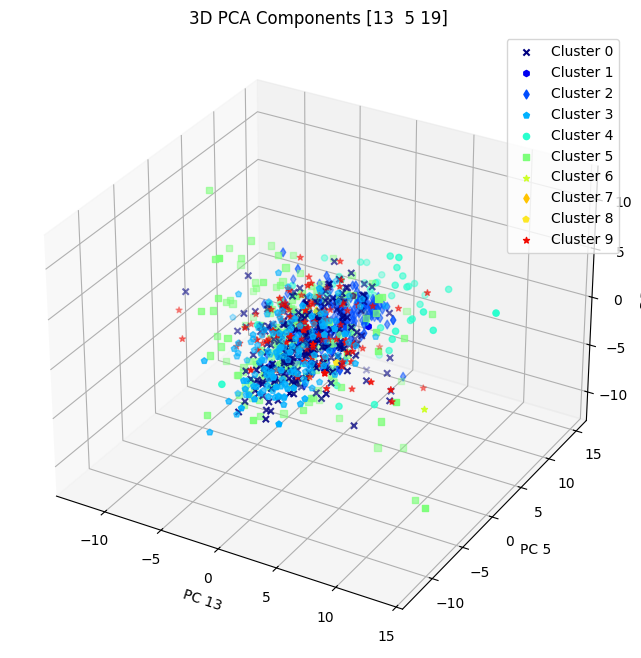

In [12]:
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# only select the random 1000 samples for visualization
X_train_mnist_pca_20 = X_train_mnist_pca_20[:1000]
X_train_mnist_scaled = X_train_mnist_scaled[:1000]
y_train_mnist = y_train_mnist[:1000]

# A) KMeans Clustering
n_clusters = 10
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_train_mnist_scaled)  # Ensure correct variable name
print(f"KMeans Clustering Labels: {np.unique(cluster_labels)}")
# C) 3D Visualization with PCA + t-SNE
# Using 20 PCA components reduced to 3D with t-SNE
tsne = TSNE(n_components=3, random_state=42)
X_tsne = tsne.fit_transform(X_train_mnist_pca_20)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
markers = ['o', '^', '+', '*', 's', 'd', 'p', 'h', 'x', 'D']

for i in range(n_clusters):
    mask = cluster_labels == i
    cluster_data = X_tsne[mask]
    true_labels = y_train_mnist[mask].astype(int)
    
    if len(true_labels) > 0:
        representative_label = true_labels.iloc[0]
        ax.scatter(cluster_data[:, 0], cluster_data[:, 1], cluster_data[:, 2],
                   c=plt.cm.jet(i / n_clusters), 
                   marker=markers[representative_label],
                   label=f'Cluster {i}')

ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_zlabel('t-SNE 3')
ax.set_title('MNIST Clusters (PCA-20 + t-SNE-3)')
ax.legend()
plt.show()

# D) Optimized Random PCA Components Visualization
def plot_random_pca(X, y, cluster_labels, random_state=None):
    """3D plot using 3 random PCA components"""
    np.random.seed(random_state)
    indices = np.random.choice(20, size=3, replace=False)
    X_subset = X[:, indices]

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    markers = ['o', '^', '+', '*', 's', 'd', 'p', 'h', 'x', 'D']

    for i in range(n_clusters):
        mask = cluster_labels == i
        cluster_data = X_subset[mask]
        true_labels = y[mask].astype(int)
        
        if len(true_labels) > 0:
            representative_label = true_labels.iloc[0]
            ax.scatter(cluster_data[:, 0], cluster_data[:, 1], cluster_data[:, 2],
                       c=plt.cm.jet(i / n_clusters),
                       marker=markers[representative_label],
                       label=f'Cluster {i}')

    ax.set_xlabel(f'PC {indices[0]+1}')
    ax.set_ylabel(f'PC {indices[1]+1}')
    ax.set_zlabel(f'PC {indices[2]+1}')
    ax.set_title(f'3D PCA Components {indices+1}')
    ax.legend()
    plt.show()

# Generate 3 random visualizations
for i in range(3):
    plot_random_pca(X_train_mnist_pca_20, y_train_mnist, cluster_labels, random_state=i)

# PROBLEM 5 : Implement Kernel PCA for Logistic Regression

[TwoSpirals] Linear Model Accuracy: 0.7125
[ThreeCircles] Linear Model Accuracy: 0.1100

Evaluating TwoSpirals:
T = 10, Accuracy = 0.7275
T = 20, Accuracy = 0.7275
T = 30, Accuracy = 0.7300
T = 40, Accuracy = 0.7300
T = 50, Accuracy = 0.7300
T = 60, Accuracy = 0.7300
T = 70, Accuracy = 0.7275
T = 80, Accuracy = 0.7300
T = 90, Accuracy = 0.7300
T = 100, Accuracy = 0.7275


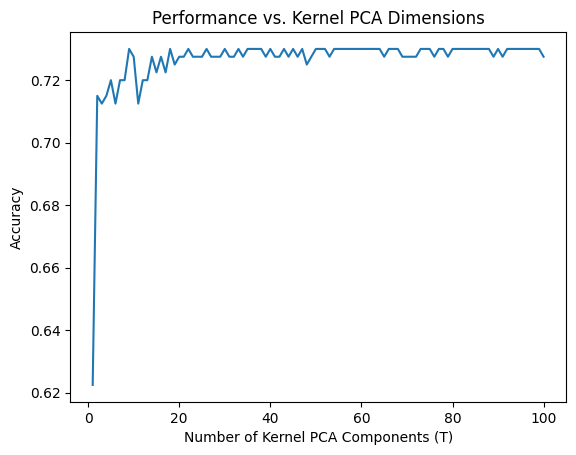


Evaluating ThreeCircles:
T = 10, Accuracy = 0.5550
T = 20, Accuracy = 0.5550
T = 30, Accuracy = 0.5550
T = 40, Accuracy = 0.5550
T = 50, Accuracy = 0.5550
T = 60, Accuracy = 0.5550
T = 70, Accuracy = 0.5550
T = 80, Accuracy = 0.5550
T = 90, Accuracy = 0.5550
T = 100, Accuracy = 0.5550


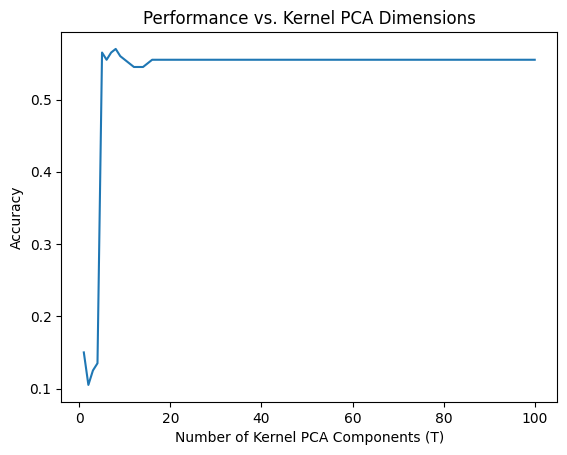

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

# ==================================================
# Dataset Generation
# ==================================================

def generate_two_spirals(n_samples=1000, noise=0.5):
    """Generate TwoSpirals dataset."""
    theta = np.sqrt(np.random.rand(n_samples)) * 2 * np.pi
    r = np.linspace(0, 1, n_samples)
    x1 = r * np.cos(theta) * 2 * np.pi + np.random.randn(n_samples) * noise
    y1 = r * np.sin(theta) * 2 * np.pi + np.random.randn(n_samples) * noise
    x2 = r * np.cos(theta + np.pi) * 2 * np.pi + np.random.randn(n_samples) * noise
    y2 = r * np.sin(theta + np.pi) * 2 * np.pi + np.random.randn(n_samples) * noise
    X = np.vstack([np.column_stack([x1, y1]), np.column_stack([x2, y2])])
    y = np.hstack([np.zeros(n_samples), np.ones(n_samples)])
    return X, y

def generate_three_circles(n_samples=1000, noise=0.05):
    """Generate ThreeCircles dataset."""
    X1, y1 = make_circles(n_samples=n_samples//3, noise=noise, factor=0.3)
    X2, y2 = make_circles(n_samples=n_samples//3, noise=noise, factor=0.6)
    X3, y3 = make_circles(n_samples=n_samples//3, noise=noise, factor=0.9)
    X = np.vstack([X1, X2, X3])
    y = np.hstack([y1, y2 + 2, y3 + 4])  # 3 classes: 0, 1, 2
    return X, y

# ==================================================
# Part A: Baseline Logistic Regression
# ==================================================

def evaluate_linear_model(X, y, dataset_name):
    """Train Logistic Regression and report accuracy."""
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    lr = LogisticRegression(max_iter=1000)
    lr.fit(X_train, y_train)
    y_pred = lr.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"[{dataset_name}] Linear Model Accuracy: {acc:.4f}")

# Generate datasets and evaluate
X_spiral, y_spiral = generate_two_spirals()
X_circle, y_circle = generate_three_circles()

evaluate_linear_model(X_spiral, y_spiral, "TwoSpirals")
evaluate_linear_model(X_circle, y_circle, "ThreeCircles")

# ==================================================
# Part B: Kernel PCA Implementation
# ==================================================

def kernel_pca(X, sigma=3, n_components=3):
    """Kernel PCA with Gaussian kernel."""
    # Compute pairwise squared Euclidean distances
    X_norm = np.sum(X**2, axis=1)
    DIST = X_norm[:, None] + X_norm[None, :] - 2 * X @ X.T
    
    # Compute kernel matrix
    K = np.exp(-DIST / sigma)
    
    # Center the kernel matrix
    N = K.shape[0]
    U = np.ones((N, N)) / N
    K_centered = K - U @ K - K @ U + U @ K @ U
    
    # Eigen decomposition
    eigvals, eigvecs = np.linalg.eigh(K_centered)
    sorted_idx = np.argsort(eigvals)[::-1]  # Sort descending
    eigvecs = eigvecs[:, sorted_idx]
    
    # Project data
    X_transformed = K_centered @ eigvecs
    return X_transformed[:, :n_components]

# Apply Kernel PCA
scaler = StandardScaler()
X_spiral_scaled = scaler.fit_transform(X_spiral)
X_spiral_kpca3 = kernel_pca(X_spiral_scaled, sigma=3, n_components=3)
X_spiral_kpca20 = kernel_pca(X_spiral_scaled, sigma=3, n_components=20)
X_spiral_kpca100 = kernel_pca(X_spiral_scaled, sigma=3, n_components=100)

# ==================================================
# Part C: Retrain Model on Kernel PCA Features
# ==================================================

def evaluate_kernel_pca_performance(X, y, max_components=100):
    """Evaluate Logistic Regression on varying Kernel PCA components."""
    X_scaled = StandardScaler().fit_transform(X)
    accuracies = []
    
    # Compute all components up front (efficient)
    X_kpca = kernel_pca(X_scaled, sigma=3, n_components=max_components)
    
    for T in range(1, max_components + 1):
        X_transformed = X_kpca[:, :T]
        X_train, X_test, y_train, y_test = train_test_split(
            X_transformed, y, test_size=0.2, random_state=42
        )
        lr = LogisticRegression(max_iter=1000)
        lr.fit(X_train, y_train)
        acc = accuracy_score(y_test, lr.predict(X_test))
        accuracies.append(acc)
        if T % 10 == 0:
            print(f"T = {T}, Accuracy = {acc:.4f}")
    
    # Plot results
    plt.plot(range(1, max_components + 1), accuracies)
    plt.xlabel("Number of Kernel PCA Components (T)")
    plt.ylabel("Accuracy")
    plt.title("Performance vs. Kernel PCA Dimensions")
    plt.show()

print("\nEvaluating TwoSpirals:")
evaluate_kernel_pca_performance(X_spiral, y_spiral, max_components=100)

print("\nEvaluating ThreeCircles:")
evaluate_kernel_pca_performance(X_circle, y_circle, max_components=100)